In [14]:
!pip install kagglehub scikit-fuzzy opencv-python scikit-image
import kagglehub
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import skfuzzy as fuzz
from glob import glob

In [15]:
path = kagglehub.dataset_download("paultimothymooney/blood-cells")
print("Dataset Path = ", path)

Using Colab cache for faster access to the 'blood-cells' dataset.
Dataset Path =  /kaggle/input/blood-cells


In [16]:
image_dirs = glob(path + "/**/images", recursive=True)
base_images = image_dirs[0]

print("Images root folders = ", os.listdir(base_images))
train_path = os.path.join(base_images, "TRAIN")
print("\nClasses inside TRAIN = ")
print(os.listdir(train_path))

class_name = os.listdir(train_path)[0]
class_folder = os.path.join(train_path, class_name)

print("\nUsing class =", class_name)
image_files = glob(class_folder + "/*.jpeg") + \
              glob(class_folder + "/*.jpg") + \
              glob(class_folder + "/*.png")

print("Total images =", len(image_files))

images = []
for p in image_files[:5]:
    img = cv2.imread(p)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    images.append(img)

print("Loaded images = ", len(images))

Images root folders =  ['TEST_SIMPLE', 'TEST', 'TRAIN']

Classes inside TRAIN = 
['MONOCYTE', 'NEUTROPHIL', 'LYMPHOCYTE', 'EOSINOPHIL']

Using class = MONOCYTE
Total images = 2478
Loaded images =  5


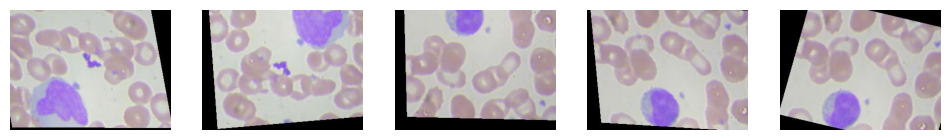

In [17]:
plt.figure(figsize=(12,4))
for i,img in enumerate(images):
    plt.subplot(1,len(images),i+1)
    plt.imshow(img)
    plt.axis("off")
plt.show()

In [18]:
def kmeans_segmentation(image, k=3):
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    h,w,c = lab.shape
    pixels = lab.reshape((-1,3)).astype(np.float32)
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(pixels)
    return labels.reshape(h,w)

In [19]:
def fuzzy_segmentation(image, c=3):
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    h,w,ch = lab.shape

    pixels = lab.reshape((-1,3)).astype(np.float32)
    pixels_T = pixels.T

    cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
        pixels_T, c=c, m=2, error=0.005, maxiter=1000
    )
    labels = np.argmax(u, axis=0)
    return labels.reshape(h,w)

In [20]:
def extract_dark_cluster(seg, image):
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    pixels = lab.reshape((-1,3))

    means = []
    for i in range(3):
        means.append(np.mean(pixels[seg.reshape(-1)==i]))

    nucleus_cluster = np.argmin(means)
    mask = (seg == nucleus_cluster).astype(np.uint8)*255
    return mask

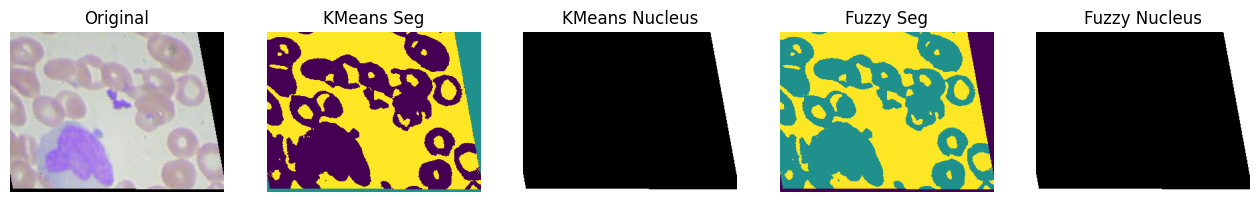

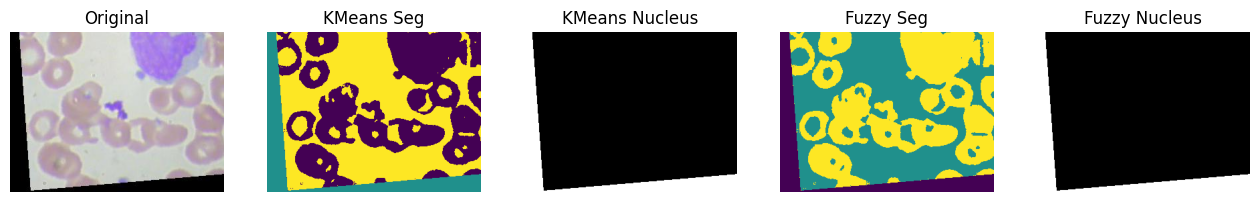

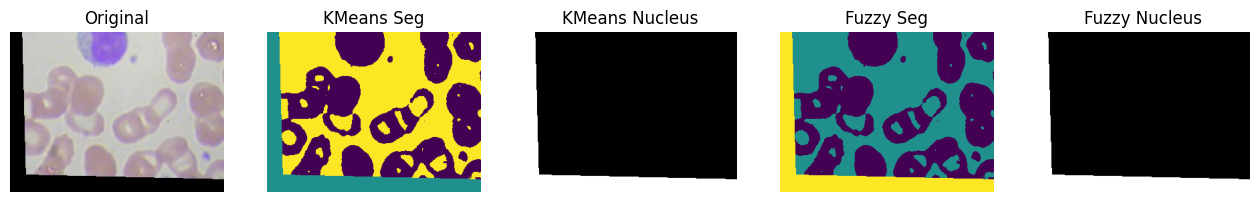

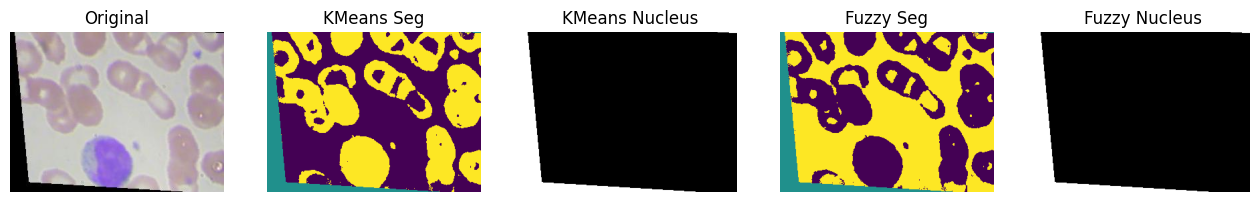

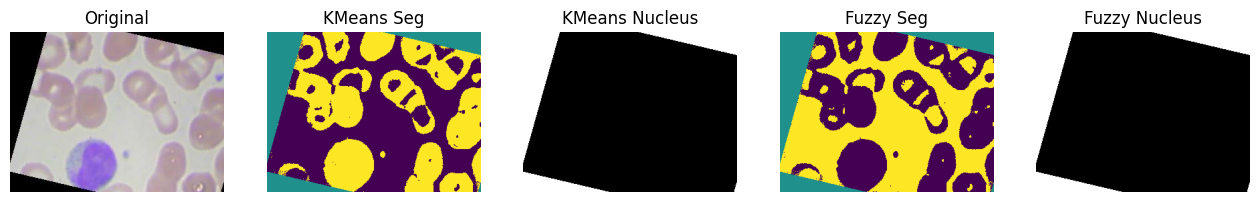

In [21]:
for img in images:

    seg_km = kmeans_segmentation(img)
    seg_fcm = fuzzy_segmentation(img)

    mask_km = extract_dark_cluster(seg_km, img)
    mask_fcm = extract_dark_cluster(seg_fcm, img)

    plt.figure(figsize=(16,4))

    plt.subplot(1,5,1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,5,2)
    plt.imshow(seg_km, cmap="viridis")
    plt.title("KMeans Seg")
    plt.axis("off")

    plt.subplot(1,5,3)
    plt.imshow(mask_km, cmap="gray")
    plt.title("KMeans Nucleus")
    plt.axis("off")

    plt.subplot(1,5,4)
    plt.imshow(seg_fcm, cmap="viridis")
    plt.title("Fuzzy Seg")
    plt.axis("off")

    plt.subplot(1,5,5)
    plt.imshow(mask_fcm, cmap="gray")
    plt.title("Fuzzy Nucleus")
    plt.axis("off")

    plt.show()

In [22]:
def dice_score(pred, gt):
    pred = pred>0
    gt = gt>0
    inter = np.logical_and(pred, gt).sum()
    return 2*inter/(pred.sum()+gt.sum())